### Imporrt Deps

In [3]:
import json 
import gzip
import pandas as pd

### Working with downlaoded data

In [9]:
with open('../../data/meta_Electronics.jsonl', 'rt') as f:
    for i, line in enumerate(f):
        if i >= 5:
            break
        print(json.loads(line))

{'main_category': 'All Electronics', 'title': 'FS-1051 FATSHARK TELEPORTER V3 HEADSET', 'average_rating': 3.5, 'rating_number': 6, 'features': [], 'description': ['Teleporter V3 The “Teleporter V3” kit sets a new level of value in the FPV world with Fat Shark renowned performance and quality. The fun of FPV is experienced firsthand through the large screen FPV headset with integrated NexwaveRF receiver technology while simultaneously recording onboard HD footage with the included “PilotHD” camera. The “Teleporter V3” kit comes complete with everything you need to step into the cockpit of your FPV vehicle. We’ve included our powerful 250mW 5.8Ghz transmitter, 25 degree FOV headset (largest QVGA display available), the brand new “PilotHD” camera with live AV out and all the cables, antennas and connectors needed.'], 'price': None, 'images': [{'thumb': 'https://m.media-amazon.com/images/I/41qrX56lsYL._AC_US40_.jpg', 'large': 'https://m.media-amazon.com/images/I/41qrX56lsYL._AC_.jpg', 'var


| Field | Type | Notes |
|---|---|---|
| `main_category` | `str` | Top-level category, e.g. `"All Electronics"` |
| `title` | `str` | Product name |
| `average_rating` | `float` | Mean star rating (1.0â5.0) |
| `rating_number` | `int` | Count of ratings |
| `features` | `list[str]` | Bullet-point features (often `[]`) |
| `description` | `list[str]` | Paragraphs of description text |
| `price` | `float \| None` | Often `None` when unavailable |
| `images` | `list[dict]` | Each: `{thumb, large, hi_res, variant}` â values are URL strings or `None` |
| `videos` | `list[dict]` | Each: `{title, url, user_id}` (often `[]`) |
| `store` | `str \| None` | Brand / storefront name |
| `categories` | `list[str]` | Category breadcrumb path |
| `details` | `dict[str, Any]` | Free-form key/value spec table â keys vary per product |
| `parent_asin` | `str` | Product group ID (joins to reviews) |
| `bought_together` | `list[str] \| None` | Related ASINs, usually `None` |

### Filter out only recemt items (appeared in stock 2022 or 2023)
    we will use details : ( data first available: x }

In [28]:
def filter_data_by_date(data: dict) -> bool:
    filter = False 
    if int(data["details"]["Date First Available"][-4:]) < 2022:
        filter = True
    return filter

In [33]:
test_dict = {'main_category': 'All Electronics', 'title': 'FS-1051 FATSHARK TELEPORTER V3 HEADSET', 'average_rating': 3.5, 'rating_number': 6, 'features': [], 'description': ['Teleporter V3 The “Teleporter V3” kit sets a new level of value in the FPV world with Fat Shark renowned performance and quality. The fun of FPV is experienced firsthand through the large screen FPV headset with integrated NexwaveRF receiver technology while simultaneously recording onboard HD footage with the included “PilotHD” camera. The “Teleporter V3” kit comes complete with everything you need to step into the cockpit of your FPV vehicle. We’ve included our powerful 250mW 5.8Ghz transmitter, 25 degree FOV headset (largest QVGA display available), the brand new “PilotHD” camera with live AV out and all the cables, antennas and connectors needed.'], 'price': None, 'images': [{'thumb': 'https://m.media-amazon.com/images/I/41qrX56lsYL._AC_US40_.jpg', 'large': 'https://m.media-amazon.com/images/I/41qrX56lsYL._AC_.jpg', 'variant': 'MAIN', 'hi_res': None}], 'videos': [], 'store': 'Fat Shark', 'categories': ['Electronics', 'Television & Video', 'Video Glasses'], 'details': {'Date First Available': 'August 2, 2014', 'Manufacturer': 'Fatshark'}, 'parent_asin': 'B00MCW7G9M', 'bought_together': None}

In [34]:
filter_data_by_date(test_dict)

True

In [37]:
with open('../../data/meta_Electronics.jsonl', 'rt') as fp:
    with open('../../data/meta_Electronics.2022_2023.jsonl', 'a', encoding='utf-8') as fp_out:
        with open('../../data/meta_Electronics.2022_2023_no_date.jsonl', 'a', encoding='utf-8') as fp_out_no_data:
            i = 0
            for line in fp:
                data = json.loads(line.strip())
                try:
                    filter = filter_data_by_date(data)
                    if not filter:
                        json.dump(data, fp_out)
                        fp_out.write('\n')
                        fp_out.flush()
                except:
                    json.dump(data, fp_out_no_data)
                    fp_out_no_data.write('\n')
                    fp_out_no_data.flush()
                i += 1
                if i % 1000 == 0:
                    print(f"Processed {i} lines")

Processed 1000 lines
Processed 2000 lines
Processed 3000 lines
Processed 4000 lines
Processed 5000 lines
Processed 6000 lines
Processed 7000 lines
Processed 8000 lines
Processed 9000 lines
Processed 10000 lines
Processed 11000 lines
Processed 12000 lines
Processed 13000 lines
Processed 14000 lines
Processed 15000 lines
Processed 16000 lines
Processed 17000 lines
Processed 18000 lines
Processed 19000 lines
Processed 20000 lines
Processed 21000 lines
Processed 22000 lines
Processed 23000 lines
Processed 24000 lines
Processed 25000 lines
Processed 26000 lines
Processed 27000 lines
Processed 28000 lines
Processed 29000 lines
Processed 30000 lines
Processed 31000 lines
Processed 32000 lines
Processed 33000 lines
Processed 34000 lines
Processed 35000 lines
Processed 36000 lines
Processed 37000 lines
Processed 38000 lines
Processed 39000 lines
Processed 40000 lines
Processed 41000 lines
Processed 42000 lines
Processed 43000 lines
Processed 44000 lines
Processed 45000 lines
Processed 46000 lin

### split items into two categories: "has_main_category","does_not_have_main_category"

In [38]:
def filter_categorgy(data: dict) -> dict:
    filter = False
    if data['main_category'] == None:
        filter = True
    
    return filter

In [39]:
with open('../../data/meta_Electronics.2022_2023.jsonl', 'rt') as fp:
    with open('../../data/meta_Electronics_2022_2023_with_category.jsonl', 'a', encoding='utf-8') as fp_out:
        with open('../../data/meta_Electronics_2022_2023_no_category.jsonl', 'a', encoding='utf-8') as fp_out_no_category:
            i = 0
            for line in fp:
                data = json.loads(line.strip())
                if not filter_categorgy(data):
                    json.dump(data, fp_out)
                    fp_out.write('\n')
                    fp_out.flush()
                else:
                    json.dump(data, fp_out_no_category)
                    fp_out_no_category.write('\n')
                    fp_out_no_category.flush()
                i += 1
                if i % 10000 == 0:
                    print(f"Processed {i} lines")

Processed 10000 lines
Processed 20000 lines
Processed 30000 lines
Processed 40000 lines
Processed 50000 lines
Processed 60000 lines
Processed 70000 lines
Processed 80000 lines
Processed 90000 lines
Processed 100000 lines
Processed 110000 lines


### Explore distribution by categories

In [40]:
df = pd.read_json('../../data/meta_Electronics_2022_2023_with_category.jsonl', lines=True)

In [41]:
df.head()

,main_category,title,average_rating,rating_number,features,description,price,images,videos,store,categories,details,parent_asin,bought_together,subtitle,author
0,Amazon Home,"Outer Space Planets Stickers(50Pcs),Planetary ...",4.5,50,[PROFESSIONAL STICKER SHOP.There are 50 differ...,"[Features:, - Clear picture and exquisite prin...",3.99,[{'thumb': 'https://m.media-amazon.com/images/...,[{'title': 'Watch Before Buying! Huge Waterpro...,Affoto,"[Electronics, Computers & Accessories, Laptop ...","{'Brand': 'Affoto', 'Color': 'Outer Space', 'S...",B0BPLX8B2K,NaN,NaN,NaN
1,Computers,"Gateway 15.6"" FHD Ultra Slim Budget Notebook, ...",4.1,15,"[【Processor】4 Core, 4 Threads, 4MB Cache, up t...","[Processor:, Intel® Pentium® Silver N5030 Proc...",189.99,[{'thumb': 'https://m.media-amazon.com/images/...,"[{'title': 'Watch before you order ', 'url': '...",Gateway,"[Electronics, Computers & Accessories, Compute...",{'Standing screen display size': '15.6 Inches'...,B0BYBG1PPD,NaN,NaN,NaN
2,Cell Phones & Accessories,May Chen Compatible with MacBook Pro 16 inch C...,4.5,649,[【 COMPATIBLE WITH 】 Designed to Fits Perfectl...,[May Chen High Quality Plastic Hard Shell Case...,26.99,[{'thumb': 'https://m.media-amazon.com/images/...,[{'title': 'MOSISO Plastic Hard Shell Compati...,May Chen,"[Electronics, Computers & Accessories, Laptop ...","{'Standing screen display size': '16 Inches', ...",B0822SL7JX,NaN,NaN,NaN
3,All Electronics,"LENTION USB C Docking Station, 10 Gbps USB C&U...",4.4,16,[10-in-1 Docking Station - CB-D65 laptop docki...,[],89.99,[{'thumb': 'https://m.media-amazon.com/images/...,[{'title': 'LENTION D65 Upgrade Docking Statio...,LENTION,"[Electronics, Computers & Accessories, Laptop ...",{'Package Dimensions': '9.17 x 4.33 x 1.54 inc...,B0BKS1K986,NaN,NaN,NaN
4,All Electronics,1X (No Bluetooth) Eaglewireless Replacement To...,3.0,4,[],[],NaN,[{'thumb': 'https://m.media-amazon.com/images/...,[],Eaglewireless,[],{'Package Dimensions': '5.2 x 2.13 x 0.91 inch...,B09MY246CC,NaN,NaN,NaN


we can see the see the actual description is sparse - so we wil also use the features col 

we need to install matplotlib to graph the data

```
uv add --dev matplotlib
```

Matplotlib is building the font cache; this may take a moment.


<Axes: xlabel='main_category'>

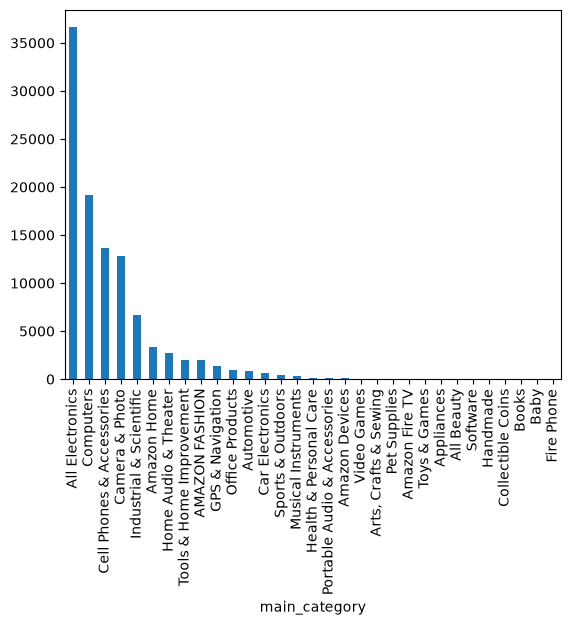

In [44]:
df["main_category"].value_counts().plot(kind="bar")

when we sample this data down we want to keep the above distribution 

so we will keep the items with 100 reviews or more

In [47]:
df_ratings_100 = df[df["rating_number"] >= 100]

In [48]:
len(df_ratings_100)

17290

<Axes: xlabel='main_category'>

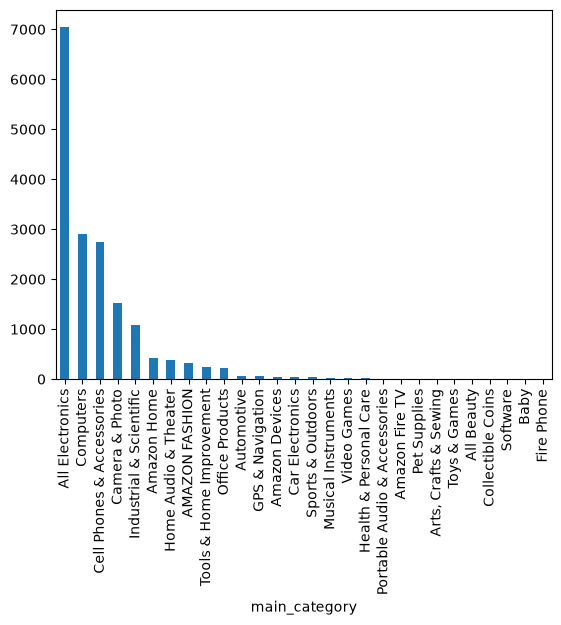

In [49]:
df_ratings_100["main_category"].value_counts().plot(kind="bar")

### Explore distribution of ratings

<Axes: ylabel='Frequency'>

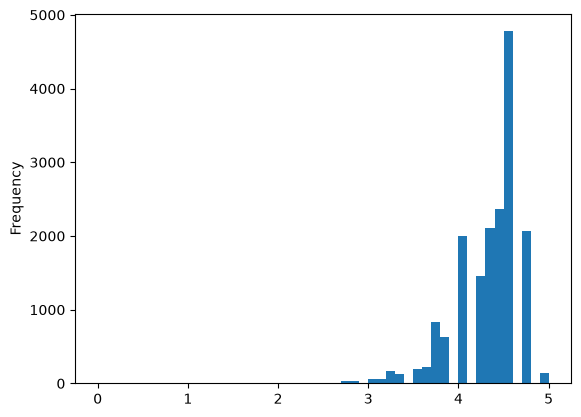

In [50]:
df_ratings_100["average_rating"].plot(kind="hist", bins=50, range=(0, 5))

### one more down sample 

In [53]:
df_sample_1000 = df_ratings_100.sample(n=1000, random_state=42)

<Axes: ylabel='Frequency'>

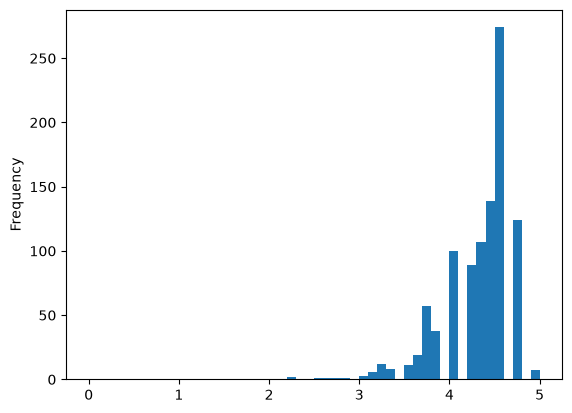

In [54]:
df_sample_1000["average_rating"].plot(kind="hist", bins=50, range=(0, 5))

<Axes: ylabel='Frequency'>

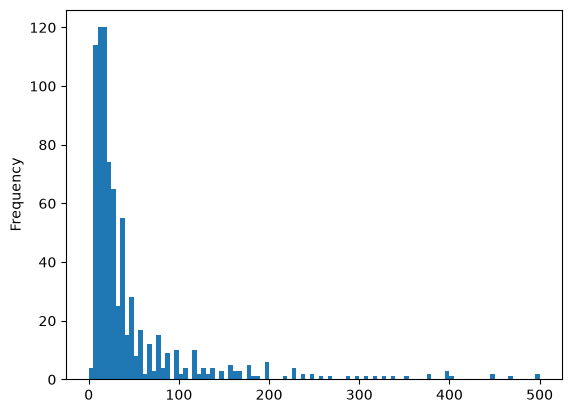

In [56]:
df_sample_1000["price"].plot(kind="hist", bins=100, range=(0, 500))

<Axes: xlabel='main_category'>

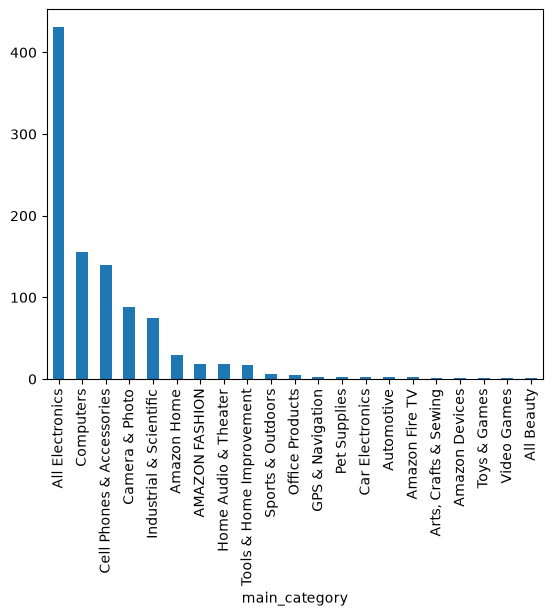

In [58]:
df_sample_1000["main_category"].value_counts().plot(kind="bar")

distributions look the same if not very similar

lets now save this sampled set

In [63]:
df_ratings_100.to_json("../../data/meta_Electronics_2022_2023_with_category_ratings_100.jsonl", orient='records', lines=True)
df_sample_1000.to_json("../../data/meta_Electronics_2022_2023_with_category_ratings_100_sample_1000.jsonl", orient='records', lines=True)

### Extracr ratings that match sampled data

In [64]:
df_ratings_100 = pd.read_json("../../data/meta_Electronics_2022_2023_with_category_ratings_100.jsonl", lines=True)
df_sample_1000 = pd.read_json("../../data/meta_Electronics_2022_2023_with_category_ratings_100_sample_1000.jsonl", lines=True)

In [65]:
with open('../../data/Electronics.jsonl', 'rt') as fp:
    with open('../../data/Electronics_2022_2023_with_category_ratings_100_sample_1000.jsonl', 'a') as fp_out:
        id_list = set(df_sample_1000['parent_asin'].values)
        i = 0
        for line in fp:
            data = json.loads(line.strip())
            if data['parent_asin'] in id_list:
                json.dump(data, fp_out)
                fp_out.write('\n')
                fp_out.flush()
            i += 1
            if i % 100000 == 0:
                print(f"Processed {i} lines")
               

Processed 100000 lines
Processed 200000 lines
Processed 300000 lines
Processed 400000 lines
Processed 500000 lines
Processed 600000 lines
Processed 700000 lines
Processed 800000 lines
Processed 900000 lines
Processed 1000000 lines
Processed 1100000 lines
Processed 1200000 lines
Processed 1300000 lines
Processed 1400000 lines
Processed 1500000 lines
Processed 1600000 lines
Processed 1700000 lines
Processed 1800000 lines
Processed 1900000 lines
Processed 2000000 lines
Processed 2100000 lines
Processed 2200000 lines
Processed 2300000 lines
Processed 2400000 lines
Processed 2500000 lines
Processed 2600000 lines
Processed 2700000 lines
Processed 2800000 lines
Processed 2900000 lines
Processed 3000000 lines
Processed 3100000 lines
Processed 3200000 lines
Processed 3300000 lines
Processed 3400000 lines
Processed 3500000 lines
Processed 3600000 lines
Processed 3700000 lines
Processed 3800000 lines
Processed 3900000 lines
Processed 4000000 lines
Processed 4100000 lines
Processed 4200000 lines
P

Amazon's publicly available product data provides a rich resource for exploring e-commerce information using product metadata and customer reviews. This overview focuses on the Electronics category and covers dataset contents, access links, data formats, and best practices for preprocessing and using the data in a Retrieval-Augmented Generation (RAG) pipeline.

Data Components and Sources

We will use open datasets compiled from Amazon’s website (for research and educational use) that include:

Product Metadata – details about products (titles, descriptions/specs, categories, etc.)

Customer Reviews – user reviews with ratings, text, and other metadata

Datasets are free for non-commercial use (e.g. academic projects) and require proper attribution to the original data compilers. Below, we provide direct download links for the Electronics category along with format and schema details.

You can find and download the data here.


1. Product Metadata (Electronics)

Description: Contains metadata for products in the Electronics category, such as titles, descriptions, pricing, category taxonomy, and related product links. This can be used to get product specifications and contextual info.

Download: meta_Electronics.jsonl.gz, link, 1.6M products, ~1.2 GB compressed. The data is openly accessible for research/educational use with attribution.

Format: JSON Lines (one product per line, in 'loose' JSON). Each line can be loaded as a Python dictionary (after decompressing the .gz file. Because it's 'loose' JSON, some lines use Python-like syntax (e.g. single quotes). You may convert it to strict JSON if needed by replacing single quotes and using a JSON library.

Data Schema (fields): You can find the descriptions here.

2. Customer Reviews (Electronics)

Description: This dataset includes Amazon customer reviews for Electronics products, including the review text, star ratings, and other metadata. Reviews provide user opinions and are useful for sentiment analysis or summarizing pros/cons.

Download: Electronics.jsonl.gz, link, 43.9M reviews, ~6 GB compressed. The data is openly accessible for research/educational use with attribution.

Format: JSON Lines (one product per line, in 'loose' JSON). Each line can be loaded as a Python dictionary (after decompressing the .gz file. Because it's 'loose' JSON, some lines use Python-like syntax (e.g. single quotes). You may convert it to strict JSON if needed by replacing single quotes and using a JSON library.

Data Schema (fields): You can find the descriptions here.


Preprocessing and Preparation

Before using these datasets for analysis or in a RAG pipeline, it’s important to preprocess and filter the data. This will make the dataset more manageable and relevant for your specific task, and improve the quality of embeddings and search results.

Selecting a Manageable Subset of Data

Working with all products or reviews in Electronics can be overwhelming (e.g., ~1.6M products, ~43.9M reviews). Consider filtering down to focus on a subset of interest:

By Popular Products: Select a subset of products that are “popular” or important. For example, you might take the top N products by number of reviews or by sales rank. This dramatically reduces data size while focusing on items that are relevant for analysis.

By Number of Reviews: A common approach is to include only products that have at least a certain number of reviews (to ensure sufficient data per product). You could, for instance, filter Electronics products to those with ≥50 reviews, which cuts down the long tail of rarely-reviewed items.

By Recency/Date: If analyzing recent trends or using RAG for current reviews, you might filter reviews to a recent time window (e.g., only reviews from the last 5 years). If you use the newer data up to 2023, you can filter timestamp to (say) 2020–2023 for a modern subset.

Random Sampling: For certain projects, a random sample of the reviews can be taken (e.g., 100k reviews out of 43.9M) to make experiments feasible. Because many reviews are redundant or similar in content, sampling can often preserve diversity while shrinking data size.

By Product Category Subtree: Even within Electronics, there are sub-categories (e.g., "Cell Phones & Accessories", "Computers", "Camera & Photo"). The categories list in metadata can be used for this hierarchical filtering.

Tip: It’s usually wise to start with a smaller subset for development to ensure your data pipeline works end-to-end, then consider scaling up if needed. For example, you might start with the top 1,000 Electronics products (and their reviews) as a pilot dataset.

Enjoy exploring the data, and happy coding with your Amazon product datasets!